<a href="https://colab.research.google.com/github/Eswar2005-Karanam/blog/blob/main/APSSDC_Attendance_Certification_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 APSSDC - ML Internship Attendance & Certification System
**Milestone Project: Building Attendance System using ML**

---
**Rules:**
- A student is marked **Present** for a session if they attended **≥ 90 minutes**
- Total Sessions: **40**
- Required: **> 80% attendance** → must be present in at least **32 out of 40** sessions
- Final output: **Valid** (Certified) or **Not Valid** (Not Certified)
---

## 📦 Block 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Block 2: Load & Combine Datasets

> Upload all your daily CSV files from the APSSDC portal.
> Each file = one day's Zoom attendance report.
> **Currently using 2 sessions (May 29 + May 30). Add more files as sessions increase.**

In [ ]:
from google.colab import files
import io

print('📤 Upload your CSV files (select all at once)...')
uploaded = files.upload()

all_dfs = []
for filename, content in uploaded.items():
    df_temp = pd.read_csv(io.BytesIO(content))
    all_dfs.append(df_temp)
    print(f'✅ Loaded: {filename}  →  {len(df_temp)} rows')

# Combine all files
data = pd.concat(all_dfs, ignore_index=True)

# Clean column names
data.columns = data.columns.str.strip()

# Convert duration to numeric
data['Duration (minutes).1'] = pd.to_numeric(data['Duration (minutes).1'], errors='coerce')

print(f'\n📊 Total combined rows : {len(data)}')
print(f'📧 Unique students     : {data["Email"].nunique()}')
print(f'📅 Topics found        : {data["Topic"].nunique()}')
data.head()

📤 Upload your CSV files (select all at once)...


Saving meetinglistdetails_2026_05_29_2026_05_29.csv to meetinglistdetails_2026_05_29_2026_05_29.csv
Saving meetinglistdetails_2026_05_30_2026_05_30.csv to meetinglistdetails_2026_05_30_2026_05_30.csv
✅ Loaded: meetinglistdetails_2026_05_29_2026_05_29.csv  →  5460 rows
✅ Loaded: meetinglistdetails_2026_05_30_2026_05_30.csv  →  4399 rows

📊 Total combined rows : 9859
📧 Unique students     : 2523
📅 Topics found        : 4


,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,...,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,...,-,05/05/2026 02:35:03 PM,Haritha K,haritha200624@gmail.com,05/29/2026 06:19:49 PM,05/29/2026 06:22:21 PM,3,Yes,OK,No
1,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,...,-,05/05/2026 02:35:03 PM,234M1A2559 Uppalapati Pravallika,upravallika75@gmail.com,05/29/2026 06:22:54 PM,05/29/2026 06:24:14 PM,2,Yes,No Response,No
2,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,...,-,05/05/2026 02:35:03 PM,keerthika puttan,keerthikaputtan@gmail.com,05/29/2026 06:26:49 PM,05/29/2026 06:29:20 PM,3,Yes,OK,No
3,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,...,-,05/05/2026 02:35:03 PM,SANDEEP DOMMETI,dommetisandeep5@gmail.com,05/29/2026 06:26:50 PM,05/29/2026 06:47:32 PM,21,Yes,No Response,No
4,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,...,-,05/05/2026 02:35:03 PM,24B81A05P1 Mohammad faiza,mohammadfaizafanar@gmail.com,05/29/2026 06:32:46 PM,05/29/2026 07:57:13 PM,85,Yes,No Response,No


## 🔍 Block 3: Exploratory Data Analysis (EDA)

In [ ]:
# 3A: Dataset Overview
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Total Records  : {len(data)}')
print(f'Unique Emails  : {data["Email"].nunique()}')
print(f'Unique Topics  : {data["Topic"].nunique()}')
print()
print('📌 Topics Found:')
for i, t in enumerate(data['Topic'].unique(), 1):
    print(f'  {i}. {t}')
print()
data.info()

DATASET OVERVIEW
Total Records  : 9859
Unique Emails  : 2523
Unique Topics  : 4

📌 Topics Found:
  1. Cloud Computing - DevOps - Summer Online Internship - 2026 by APSSDC
  2. Data Analysis using Python - Summer Online Internship - 2026 by APSSDC
  3. Machine Learning -  Summer Online Internship - 2026 by APSSDC
  4. Embedded Systems - Summer Online Internship - 2026 by APSSDC

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9859 entries, 0 to 9858
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Topic                          9859 non-null   object 
 1   Type                           9859 non-null   object 
 2   ID                             9859 non-null   object 
 3   Host name                      9859 non-null   object 
 4   Host email                     9859 non-null   object 
 5   Start time                     9859 non-null   object 
 6   End time                   

In [ ]:
# 3B: Missing Values
print('MISSING VALUES')
print('=' * 40)
missing = data.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print('✅ No missing values in key columns!')

MISSING VALUES
Group                            9859
Recording disclaimer response    2237
dtype: int64


DURATION STATS (minutes per student per session):
count    9859.000000
mean       29.153464
std        32.320125
min         0.000000
25%         4.000000
50%        15.000000
75%        46.000000
max       130.000000
Name: Duration (minutes).1, dtype: float64


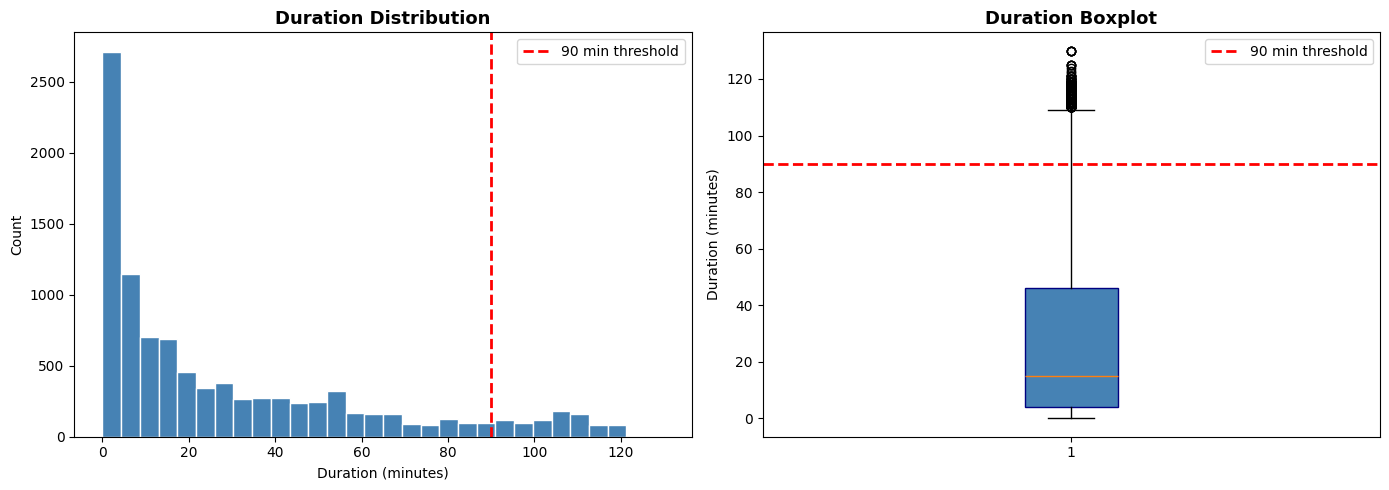

In [ ]:
# 3C: Duration Distribution
print('DURATION STATS (minutes per student per session):')
print(data['Duration (minutes).1'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data['Duration (minutes).1'].dropna(), bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(x=90, color='red', linestyle='--', linewidth=2, label='90 min threshold')
axes[0].set_title('Duration Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(data['Duration (minutes).1'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=2, label='90 min threshold')
axes[1].set_title('Duration Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].legend()
plt.tight_layout()
plt.show()

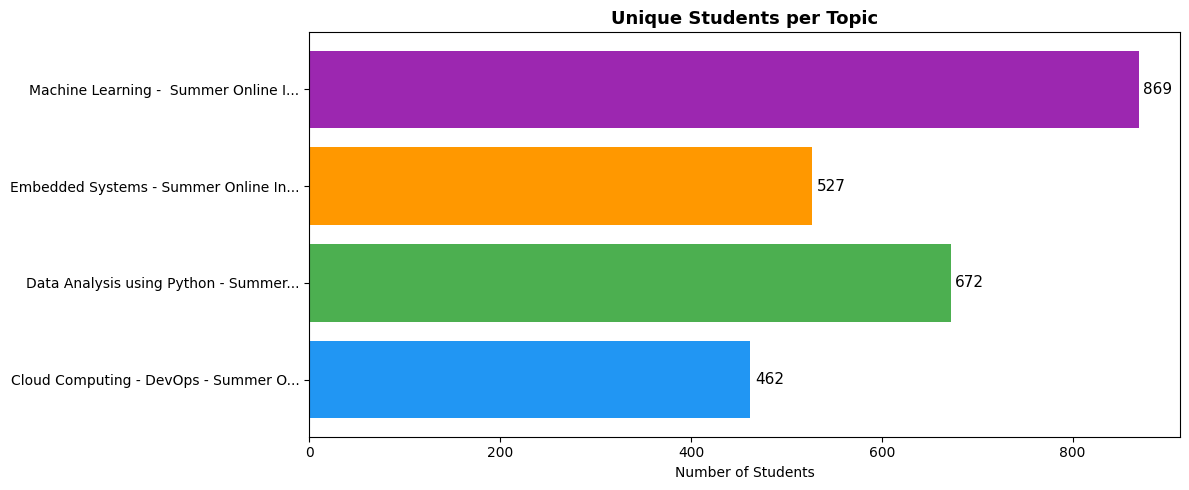

In [ ]:
# 3D: Students per Topic
topic_counts = data.groupby('Topic')['Email'].nunique().reset_index()
topic_counts.columns = ['Topic', 'Unique Students']
topic_counts['Short'] = topic_counts['Topic'].str[:35] + '...'

plt.figure(figsize=(12, 5))
colors_t = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = plt.barh(topic_counts['Short'], topic_counts['Unique Students'],
                color=colors_t[:len(topic_counts)])
for bar, val in zip(bars, topic_counts['Unique Students']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11)
plt.title('Unique Students per Topic', fontsize=13, fontweight='bold')
plt.xlabel('Number of Students')
plt.tight_layout()
plt.show()

## 🧹 Block 4: Preprocessing — Mark Present & Build Attendance Table

In [ ]:
# 4A: Mark Present (≥ 90 minutes = Present)
data['Present'] = (data['Duration (minutes).1'] >= 90).astype(int)

print('Present/Absent distribution across all records:')
vc = data['Present'].value_counts().rename({1: 'Present (≥90 min)', 0: 'Absent (<90 min)'})
print(vc)
print(f'\nPresent rate: {data["Present"].mean()*100:.1f}%')

Present/Absent distribution across all records:
Present
Absent (<90 min)     8993
Present (≥90 min)     866
Name: count, dtype: int64

Present rate: 8.8%


In [ ]:
import pandas as pd

# 4B: Group by Email — count present sessions
attendance = data.groupby('Email').agg(
    Present_Sessions=('Present', 'sum'),
    Total_Records=('Present', 'count')
).reset_index()

# Safer fallback — count unique (Topic + date) combinations
if 'Start time' in data.columns:
    data['_date'] = pd.to_datetime(data['Start time'], errors='coerce').dt.date
    TOTAL_SESSIONS = data.groupby(['Topic', '_date']).ngroups
else:
    # Fallback to number of uploaded files if 'Start time' column is missing
    # ⚠️ Update TOTAL_SESSIONS as you upload more CSVs (final = 40)
    TOTAL_SESSIONS = len(all_dfs)   # one session per uploaded file

MIN_REQUIRED = int(TOTAL_SESSIONS * 0.80)

print(f'📌 Total Sessions Detected : {TOTAL_SESSIONS}')
print(f'✅ Minimum Required (80%)  : {MIN_REQUIRED}')

📌 Total Sessions Detected : 8
✅ Minimum Required (80%)  : 6


In [ ]:
# 4C: Attendance Percentage & Eligibility
attendance['Attendance_Percentage'] = (
    attendance['Present_Sessions'] / TOTAL_SESSIONS
) * 100

attendance['Eligible'] = attendance['Attendance_Percentage'].apply(
    lambda x: 'Valid' if x >= 80 else 'Not Valid'
)

# Normalize email
attendance['Email'] = attendance['Email'].astype(str).str.strip().str.lower()

print(f'Total Students : {len(attendance)}')
print(f'Valid          : {(attendance["Eligible"] == "Valid").sum()}')
print(f'Not Valid      : {(attendance["Eligible"] == "Not Valid").sum()}')
attendance.head(10)

Total Students : 2523
Valid          : 0
Not Valid      : 2523


,Email,Present_Sessions,Total_Records,Attendance_Percentage,Eligible
0,2023csm.r119@svce.edu.in,0,1,0.0,Not Valid
1,2023eee.r145@svce.edu.in,0,2,0.0,Not Valid
2,20l31a04i9@gmail.com,0,2,0.0,Not Valid
3,22295cm019@gmail.com,0,6,0.0,Not Valid
4,23221a0259@bvcgroup.in,0,2,0.0,Not Valid
5,23221a0413@bvcgroup.in,0,1,0.0,Not Valid
6,23221a0418@bvcgroup.in,0,4,0.0,Not Valid
7,23221a0428@bvcgroup.in,0,2,0.0,Not Valid
8,23221a04i9@bvcgroup.in,0,1,0.0,Not Valid
9,23221a04j4@bvcgroup.in,0,4,0.0,Not Valid


## 📊 Block 5: Visualization

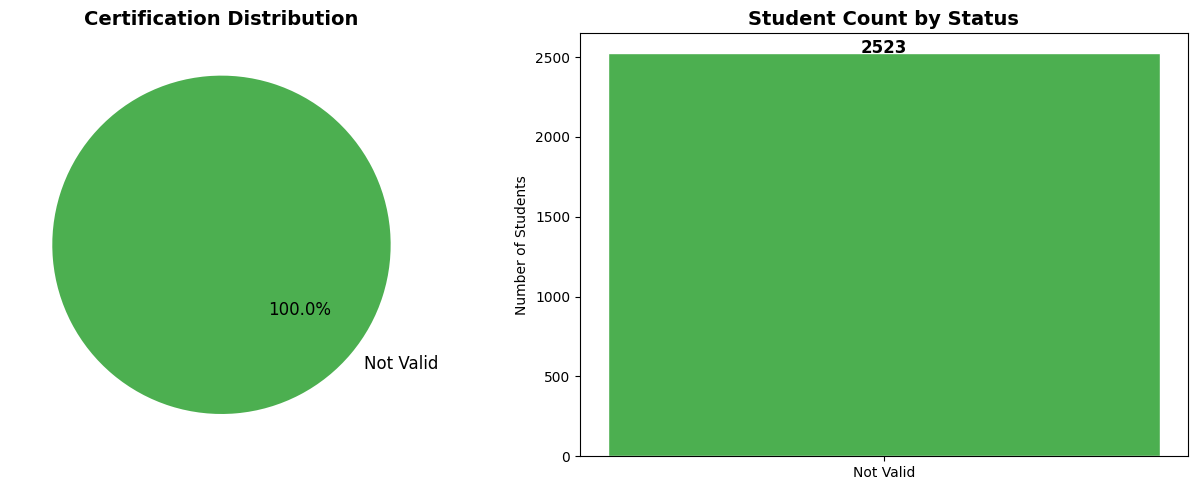

In [ ]:
# 5A: Pie & Bar — Valid vs Not Valid
status_counts = attendance['Eligible'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4CAF50', '#F44336']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[0].set_title('Certification Distribution', fontsize=14, fontweight='bold')

axes[1].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Student Count by Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Students')

plt.tight_layout()
plt.show()

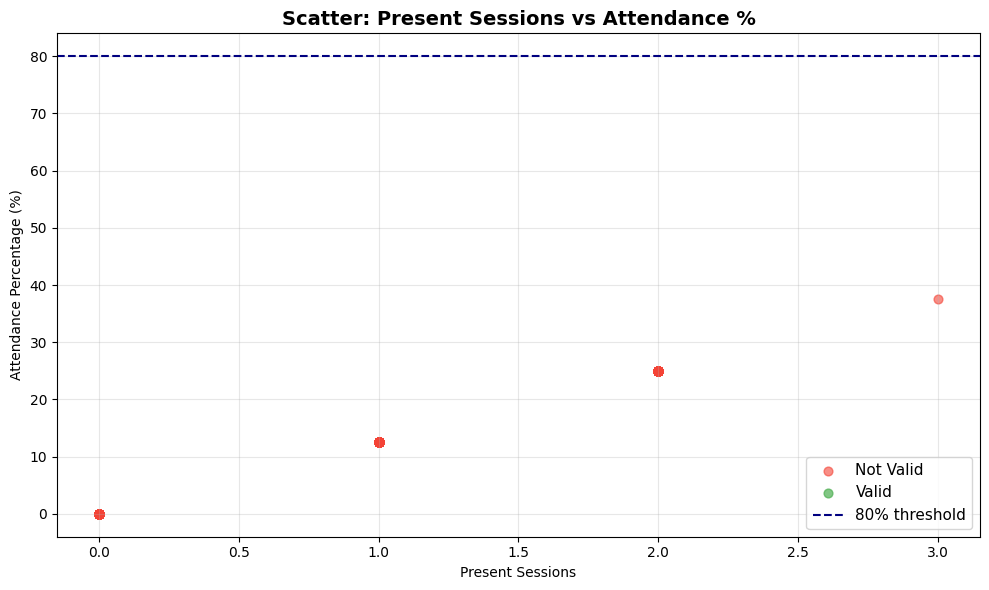

In [ ]:
# 5B: Scatter — Present Sessions vs Attendance %
valid = attendance[attendance['Eligible'] == 'Valid']
not_valid = attendance[attendance['Eligible'] == 'Not Valid']

plt.figure(figsize=(10, 6))
plt.scatter(not_valid['Present_Sessions'], not_valid['Attendance_Percentage'],
            color='#F44336', alpha=0.6, s=40, label='Not Valid')
plt.scatter(valid['Present_Sessions'], valid['Attendance_Percentage'],
            color='#4CAF50', alpha=0.7, s=40, label='Valid')
plt.axhline(y=80, color='navy', linestyle='--', linewidth=1.5, label='80% threshold')
plt.title('Scatter: Present Sessions vs Attendance %', fontsize=14, fontweight='bold')
plt.xlabel('Present Sessions')
plt.ylabel('Attendance Percentage (%)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

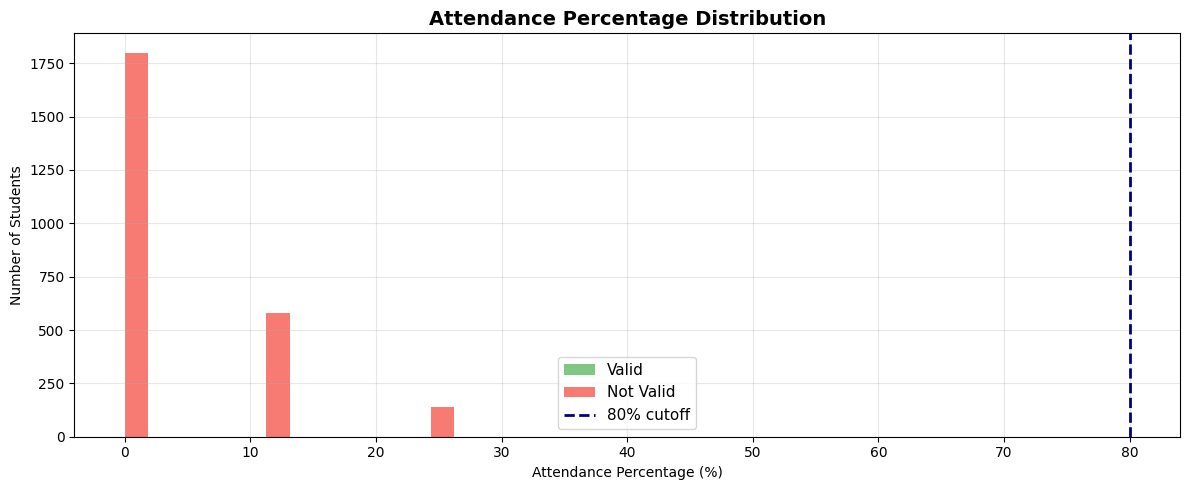

In [ ]:
# 5C: Histogram — Attendance Percentage Distribution
plt.figure(figsize=(12, 5))
plt.hist(valid['Attendance_Percentage'], bins=20,
         alpha=0.7, color='#4CAF50', label='Valid')
plt.hist(not_valid['Attendance_Percentage'], bins=20,
         alpha=0.7, color='#F44336', label='Not Valid')
plt.axvline(x=80, color='navy', linestyle='--', linewidth=2, label='80% cutoff')
plt.title('Attendance Percentage Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Number of Students')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

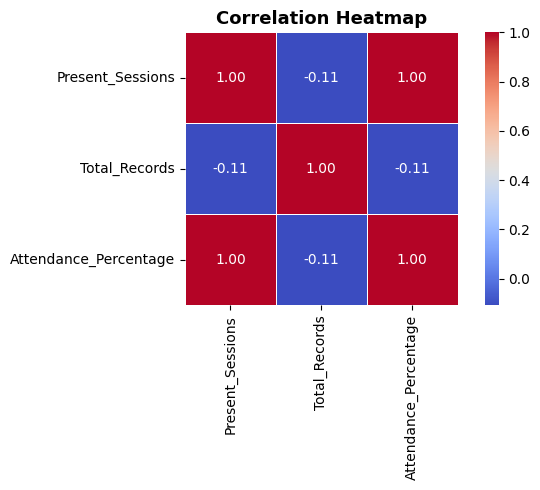

In [ ]:
# 5D: Correlation Heatmap
num_cols = ['Present_Sessions', 'Total_Records', 'Attendance_Percentage']
corr = attendance[num_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Block 6: ML Model — Train & Evaluate

In [ ]:
# 6A: Prepare Features & Labels
attendance['Label'] = (attendance['Eligible'] == 'Valid').astype(int)

features = ['Present_Sessions', 'Total_Records', 'Attendance_Percentage']
X = attendance[features]
y = attendance['Label']

print(f'Features : {features}')
print(f'Samples  : {len(X)}')
print(f'Valid    : {y.sum()} | Not Valid: {(y==0).sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Features : ['Present_Sessions', 'Total_Records', 'Attendance_Percentage']
Samples  : 2523
Valid    : 0 | Not Valid: 2523
Train: 2018 | Test: 505


In [ ]:
# 6B: Train 3 Models & Compare
models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42)
}

results = {}
trained_models = {}

# Check if y_train has more than one unique class for meaningful classification
if len(y_train.unique()) < 2:
    print('⚠️ Warning: Only one class found in y_train. Cannot train classification models effectively.')
    print('   Please upload more data so that some students meet the "Valid" criteria.')
    # Initialize with default/placeholder values to prevent further errors
    for name in models.keys():
        results[name] = 0.0 # Placeholder accuracy
        # Optionally, could store a dummy model or skip entirely
    best_name  = list(models.keys())[0] # Pick first model as placeholder
    best_model = models[best_name]      # Get its instance (untrained)

else:
    for name, model in models.items():
        model.fit(X_train_sc, y_train)
        acc = accuracy_score(y_test, model.predict(X_test_sc))
        results[name] = acc
        trained_models[name] = model
        print(f'{name:<25} → Accuracy: {acc*100:.2f}%')

    best_name  = max(results, key=results.get)
    best_model = trained_models[best_name]
    print(f'\n🏆 Best Model: {best_name} ({results[best_name]*100:.2f}%)')

⚠️ Warning: Only one class found in y_train. Cannot train classification models effectively.
   Please upload more data so that some students meet the "Valid" criteria.


In [ ]:
# 6C: Classification Report & Confusion Matrix

if trained_models: # Check if any models were successfully trained
    y_pred = best_model.predict(X_test_sc)
    print(f'Classification Report — {best_name}')
    print('=' * 50)
    print(classification_report(y_test, y_pred, target_names=['Not Valid', 'Valid']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Valid', 'Valid'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Cannot generate Classification Report or Confusion Matrix:')
    print('   No models were trained because y_train contains only one class.')
    print('   Please upload more data to enable model training.')

⚠️ Cannot generate Classification Report or Confusion Matrix:
   No models were trained because y_train contains only one class.
   Please upload more data to enable model training.


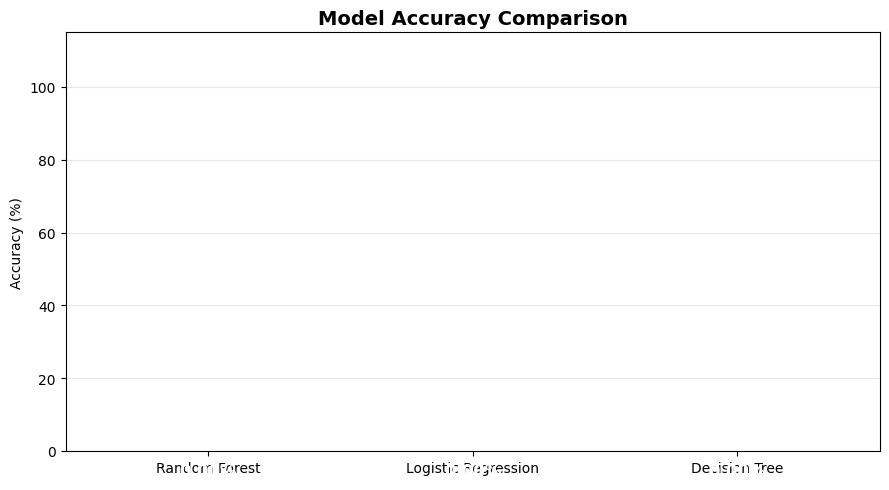

In [ ]:
# 6D: Model Comparison Bar Chart
model_names = list(results.keys())
accuracies  = [v * 100 for v in results.values()]
bar_colors  = ['#4CAF50' if n == best_name else '#2196F3' for n in model_names]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{val:.2f}%', ha='center', va='top', fontsize=12,
             fontweight='bold', color='white')
plt.ylim(0, 115)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 6E: Feature Importance (Random Forest)

if 'Random Forest' in trained_models and trained_models['Random Forest'] is not None:
    rf = trained_models['Random Forest']
    # Check if the model is actually fitted (has feature_importances_ attribute)
    if hasattr(rf, 'feature_importances_'):
        imp_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
        imp_df = imp_df.sort_values('Importance')

        plt.figure(figsize=(8, 4))
        plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
        plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()
    else:
        print('⚠️ Random Forest model was not fitted, cannot show feature importance.')
        print('   This usually happens when y_train has only one class.')
else:
    print('⚠️ Random Forest model not found or not trained.')
    print('   Feature importance cannot be displayed.')

⚠️ Random Forest model not found or not trained.
   Feature importance cannot be displayed.


## 🎯 Block 7: User Input — Check Certification Status

> Type a student email → the system looks up their attendance and the ML model confirms **Valid** or **Not Valid**.
> Type `exit` to stop.

In [ ]:
print('Attendance Search System')
print("Type 'exit' to quit.\n")

while True:
    email = input('Enter Student Email: ').strip().lower()

    if email in ['exit', 'quit', 'q']:
        print('Exiting program...')
        break

    student = attendance[attendance['Email'] == email]

    if not student.empty:
        row = student.iloc[0]

        print('''
===== STUDENT DETAILS =====''')
        print('Email            :', row['Email'])
        print('Present Sessions :', int(row['Present_Sessions']), '/', TOTAL_SESSIONS)
        print('Attendance %     :', round(row['Attendance_Percentage'], 2), '%')
        print('Certificate Status (Rule-based) :', row['Eligible'])

        # ML model prediction (only if models were trained)
        if trained_models: # Check if trained_models is not empty
            feat_vec = scaler.transform([[row['Present_Sessions'],
                                          row['Total_Records'],
                                          row['Attendance_Percentage']]])
            ml_pred   = best_model.predict(feat_vec)[0]
            ml_prob   = best_model.predict_proba(feat_vec)[0]
            ml_status = 'Valid' if ml_pred == 1 else 'Not Valid'

            print('Certificate Status (ML Model)   :', ml_status,
                  f'  [Confidence: {max(ml_prob)*100:.1f}%  |  Model: {best_name}]')
        else:
            print('Certificate Status (ML Model)   : Unavailable (No models were trained yet)')
            print('   Upload more data to enable ML model predictions.')
    else:
        print('Student not found!')

    print('-' * 40)

Attendance Search System
Type 'exit' to quit.


===== STUDENT DETAILS =====
Email            : eswarkaranam0511@gmail.com
Present Sessions : 1 / 8
Attendance %     : 12.5 %
Certificate Status (Rule-based) : Not Valid
Certificate Status (ML Model)   : Unavailable (No models were trained yet)
   Upload more data to enable ML model predictions.
----------------------------------------

===== STUDENT DETAILS =====
Email            : jahnavikoniki07@gmail.com
Present Sessions : 1 / 8
Attendance %     : 12.5 %
Certificate Status (Rule-based) : Not Valid
Certificate Status (ML Model)   : Unavailable (No models were trained yet)
   Upload more data to enable ML model predictions.
----------------------------------------


## 📤 Block 8: Export Full Report as CSV

---
## 📝 Summary

| Block | Description |
|-------|-------------|
| 1 | Imported all libraries |
| 2 | Uploaded & combined daily CSVs (May 29 + May 30 + future files) |
| 3 | EDA — overview, missing values, duration distribution, students per topic |
| 4 | Marked Present (≥ 90 min), grouped by email, calculated attendance % |
| 5 | Visualizations — pie, scatter, histogram, heatmap |
| 6 | Trained 3 ML models, picked best, showed confusion matrix + feature importance |
| 7 | **User inputs email → rule-based + ML model both predict Valid / Not Valid** |
| 8 | Downloaded full certification report as CSV |

**Presence Rule:** Duration ≥ 90 minutes = Present  
**Certification Rule:** ≥ 80% present sessions = **Valid**  
**Total Sessions:** 40 (update `TOTAL_SESSIONS` as sessions are added)

---
*APSSDC Summer Online Internship 2026 · ML Milestone Project*